# Litt bakgrunnsmateriale


## Eksempel
For å illustrere skal vi bruke et datasett, inspirert av ingen ringere enn [Donal Knuth](https://en.wikipedia.org/wiki/Donald_Knuth): Personene i [Victor Hugos](https://en.wikipedia.org/wiki/Victor_Hugo) roman [Les Misérables](https://en.wikipedia.org/wiki/Les_Mis%C3%A9rables) og deres relasjoner.  Formålet er bare å visualisere noe som ikke er så stort, slik at vi kan "se" hva som skal skje.

Orginaldata er [her](https://github.com/MADStudioNU/lesmiserables-character-network).

Naturligvis:
```
    ~> python3 -v venv
    ~> . venv/bin/activate
    (venv) ~> pip install -r requirements.txt
```
Kaffepause

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
with open("lesmiserables-character-network/parsed_data/jean-complete-node.csv", "r") as fd:
    noder_rå = fd.readlines()
#
# Bort med første linje
noder_rå = noder_rå[1:]

# Formatet er 
# "TH","Thénardier","Thénardier, innkeeper in Montfermeil, aka Jondrette"\n
# Hent ut det vi trenger, og lag noder

G = nx.Graph()
for n in noder_rå:
    _s = n.split('"')
    G.add_node(_s[1], Navn=_s[3], Rolle=_s[5])
#
print(f"Antall noder i grafen: {G.number_of_nodes()}")

# Kantene
with open("lesmiserables-character-network/parsed_data/jean-complete-edge.csv", "r") as fd:
    kanter_rå = fd.readlines()
#
# Bort med første
kanter_rå = kanter_rå[1:]
print(f"Antall kanter: {len(kanter_rå)}")
#Formatet er 
# "MY","NP","Undirected","1","1.1.1" 
# hvor 1.1.1 er kapittelet hvor forbindelsen opptrer
for k in kanter_rå:
    _s = k.split(",")
    _ = G.add_edge(_s[0][1:3], _s[1][1:3])

Antall noder i grafen: 181
Antall kanter: 1589


Vise frem hele grafen

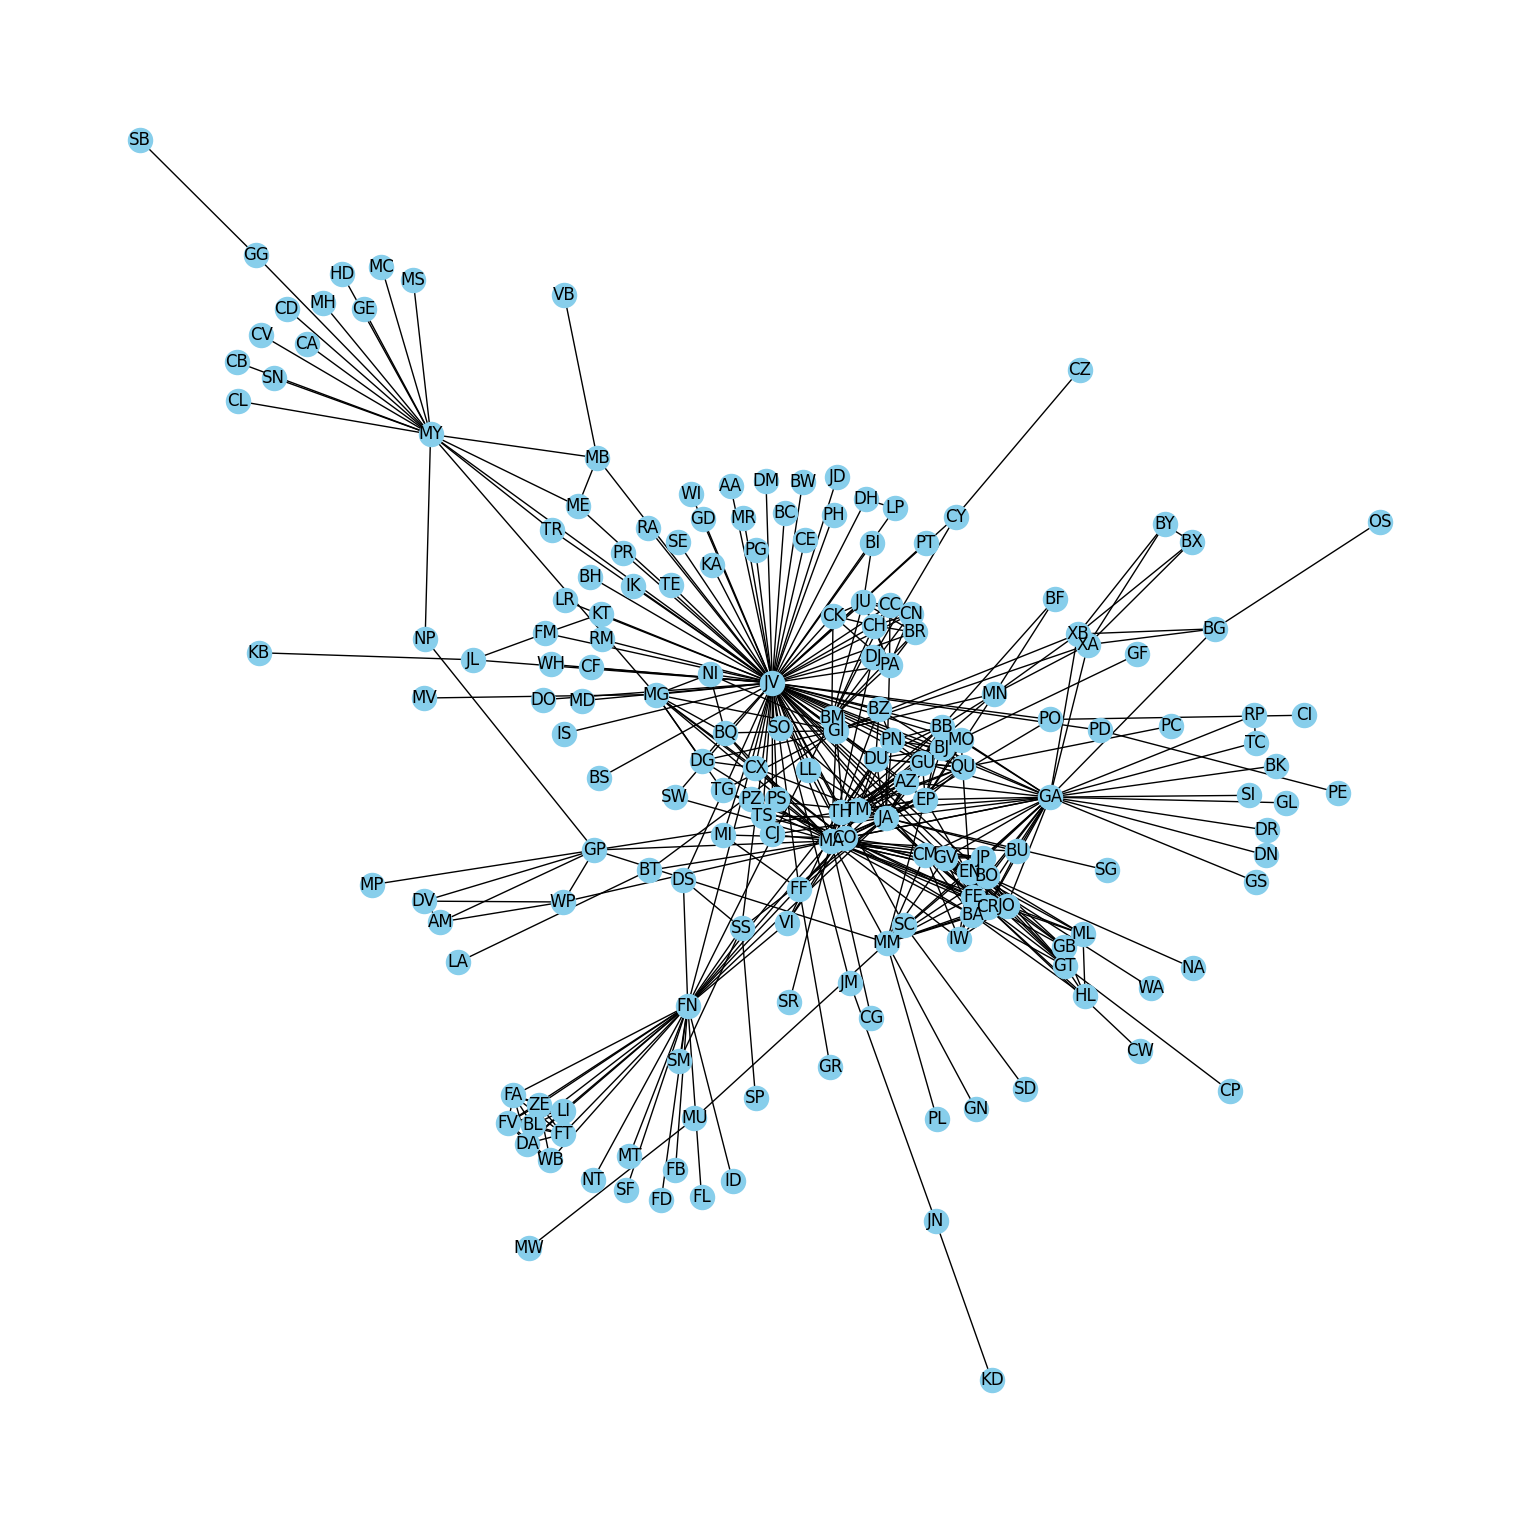

In [4]:

plt.figure(figsize=(15,15))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color="skyblue", with_labels=True)


Vi ser med et blikk at noen personer er mer sentrale enn andre, for eksempel **JV**, **FN**, og **MY**.

Vi kan lage en interaktiv visualisering med størrelsen som en logaritme av antall relasjoner

In [8]:
from ipysigma import Sigma
import math

log_degree = {}
for node, deg in G.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    G, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Sigma(nx.Graph with 181 nodes and 489 edges)

Her må man fundere over hvilken representasjon siom gir mest innsikt.  Innsikt i hva?

## Nomenklatur

### En klikk
En **klikk** er et sett med noder hvor alle har en forbindelse til alle andre.  En graf kan åpenbart ha ingen, én, eller mange klikker.  Vanligvis regner vi ikke med klikker som bar mindre enn tre medlemmer (fordi enhver kant mellom to noder da blir en klikk).  En (sub)graf som er en klikk sies å være **komplett**.  Naturligvis, alle deler av en komplett klikk er også en klikk; det interessante er å finne den maksimale klikken.

Om vi ser bort fra at at det å finne klikker i grafer lett kan bli NP-komplett ([Karp](https://en.wikipedia.org/wiki/Karp%27s_21_NP-complete_problems)) så er jo klikker steder i grafen hvor det er ekstra mye "kommunikasjon".  Hos oss lar vi klikker representere en "gjeng" hvor alle kjenner hver andre og samarbeider.

Største klikk: ['MM', 'MA', 'GA', 'CR', 'FE', 'BO', 'CM', 'JO', 'GV', 'BA', 'EN']


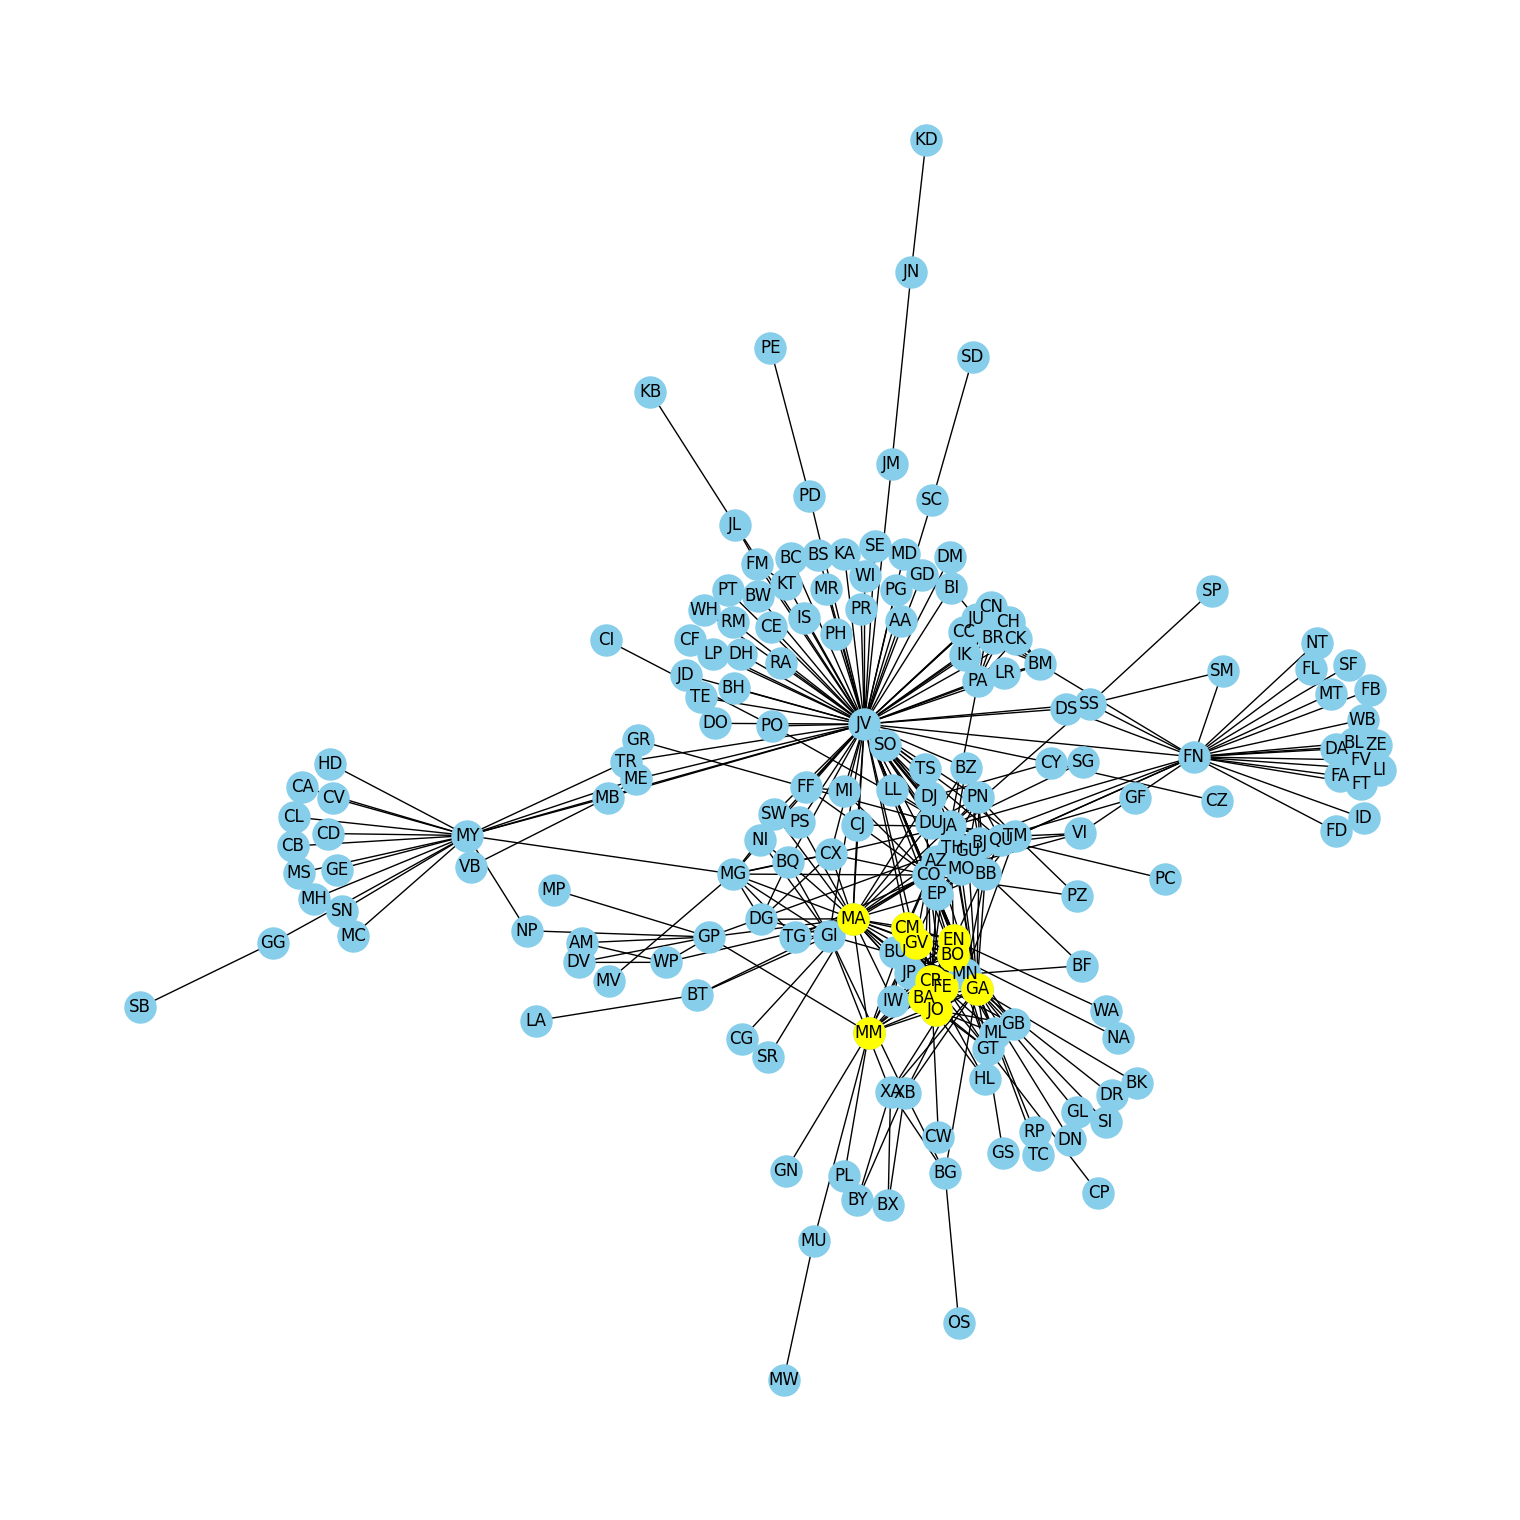

In [42]:
# Finn den største klikken i grafen
klikker = list(nx.find_cliques(G))
# Finn den lengste listen i listen av noder
klikk = max(klikker, key=len)

# Hvem er med
print("Største klikk:", klikk)

# Få se
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', font_size=12, node_size=500)

# Gi klikken en annen farge
nx.draw_networkx_nodes(G, pos, nodelist=klikk, node_color='yellow', node_size=500)
plt.show()

Klikken ser ikke ut til å være sentral i handlingen (som vi vet spiller seg ut rundt JV).  Så en klikk er i deg selv ikke nødvendigvis noe å bite seg fast i, med mindre det er av andre årsaker.

Det er mulig å hente ut klikken

	 GA {'Navn': 'Gavroche', 'Rolle': 'Gavroche, son of the Thénardiers'}
	 FE {'Navn': 'Feuilly', 'Rolle': 'Feuilly, member, Friends of the ABC'}
	 BO {'Navn': 'Bossuet', 'Rolle': 'Bossuet (Lesgle), member, Friends of the ABC'}
	 CM {'Navn': 'Combeferre', 'Rolle': 'Combeferre, member, Friends of the ABC'}
	 EN {'Navn': 'Enjolras', 'Rolle': 'Enjolras, chief of Friends of the ABC'}
	 MM {'Navn': 'M. Mabeuf', 'Rolle': 'M. Mabeuf, warden of St. Sulpice, bibliophile'}
	 BA {'Navn': 'Bahorel', 'Rolle': 'Bahorel, member, Friends of the ABC'}
	 JO {'Navn': 'Joly', 'Rolle': 'Joly, member Friends of the ABC'}
	 GV {'Navn': 'Government troops', 'Rolle': 'Government troops'}
	 MA {'Navn': 'Marius', 'Rolle': 'Marius'}
	 CR {'Navn': 'Courfeyrac', 'Rolle': 'Courfeyrac, member, Friends of the ABC'}


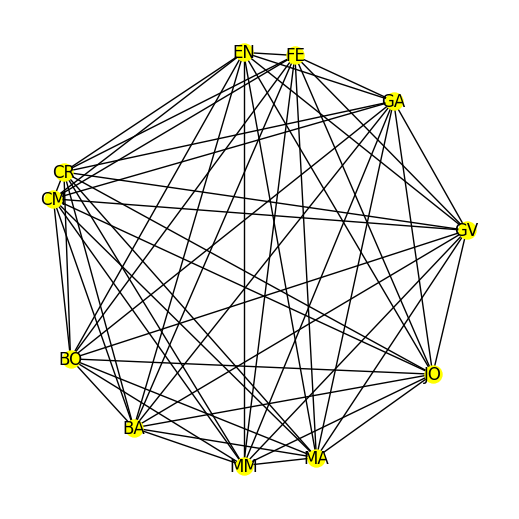

In [43]:
sg = G.subgraph(klikk)
for n in sg:
    print("\t", n, sg.nodes[n])
# 
plt.figure(figsize=(5, 5))
pos = nx.circular_layout(G)
nx.draw(sg, pos, with_labels=True, node_color='yellow', node_size=150)

Kilkker er "sterke" strukturer, som ikke oppstår så lett "uten grunn".  Vi skal returnere til klikker senere, etter at vi har sett på hva en "tilfeldig" graf er.

### Tetthet
Hvor tett en graf er avhenger av forholdet mellom antall kanter (mellom noder) mot potensielt (totalt) antall kanter.  Når vi genererer en tilfeldig graf (se nedenfor) vil tettheten være en funksjon av sannsynligheten.

Mange av algoritmene for å beregne egenskaper i grafer påvirkes av tettheten; kjøretiden avhenger sterkt av tettheten.


In [44]:
# Tettheten
tetthet = nx.density(G)
print(f"Grafens tetthet: {tetthet:.4f}")

Grafens tetthet: 0.0300


### Diameter
Den lengste korteste sti; gir et mål på maksimal avstand mellom deltagerne (nodene).  I en tilfeldig graf vil diameteren være en funksjon av antall noder.

In [45]:
# Grafens diameter
# Husk: Diameter er bare gyldig i grafer som ikke er delt.
if nx.is_connected(G):
    diameter = nx.diameter(G)
    print(f"Diameter: {diameter}")
else:
    # Dersom grafen er delt, finn største subgraf, og se på den
    største_sg = max(nx.connected_components(G), key=len)
    subgraf = G.subgraph(største_sg)
    diameter = nx.diameter(subgraf)
    print(f"Diameter (største del): {diameter}")

Diameter: 7


Dette er en roman, og med en tetthet på bare 0.03 (3%) kan det synes som om de fleste personene ikke deltar direkte i handlingen, men kanskje som "staffasje" i scener.

En diameter på 7, med en tetthet på bare 0.03, indikerer en graf med et par "tentakler" som strekker seg utover.  I handlingen kan det tyde på et par "digresjoner" hvor handlingen inkluderer person er som ellers ikke er med.

### Gjeng
Vi kan definere en **gjeng** som et sett av noder som "henger sammen" men som henger løst sammen med resten.  

#### Girvan-Newman

Vi kan bruke [Girvan-Newman](https://en.wikipedia.org/wiki/Girvan%E2%80%93Newman_algorithm) til å finne slike gjenger.  

Konseptet med en bronode er at mange korteste-sti passerer gjennom noden (som gjør den sentral sett i lys av informasjonsspredning).  Vi kan flytte fokus fra nodene til kantene, og sette vekt på kantene basert på hvor mange korteste-sti som går gjennom dem.  Ved å fjerne kanter med høy vekt fragmenteres grafen, og gjengene står igjen.  De som først separeres ut er de som har bronoder som har få (men viktige) forbindelser til resten.


181


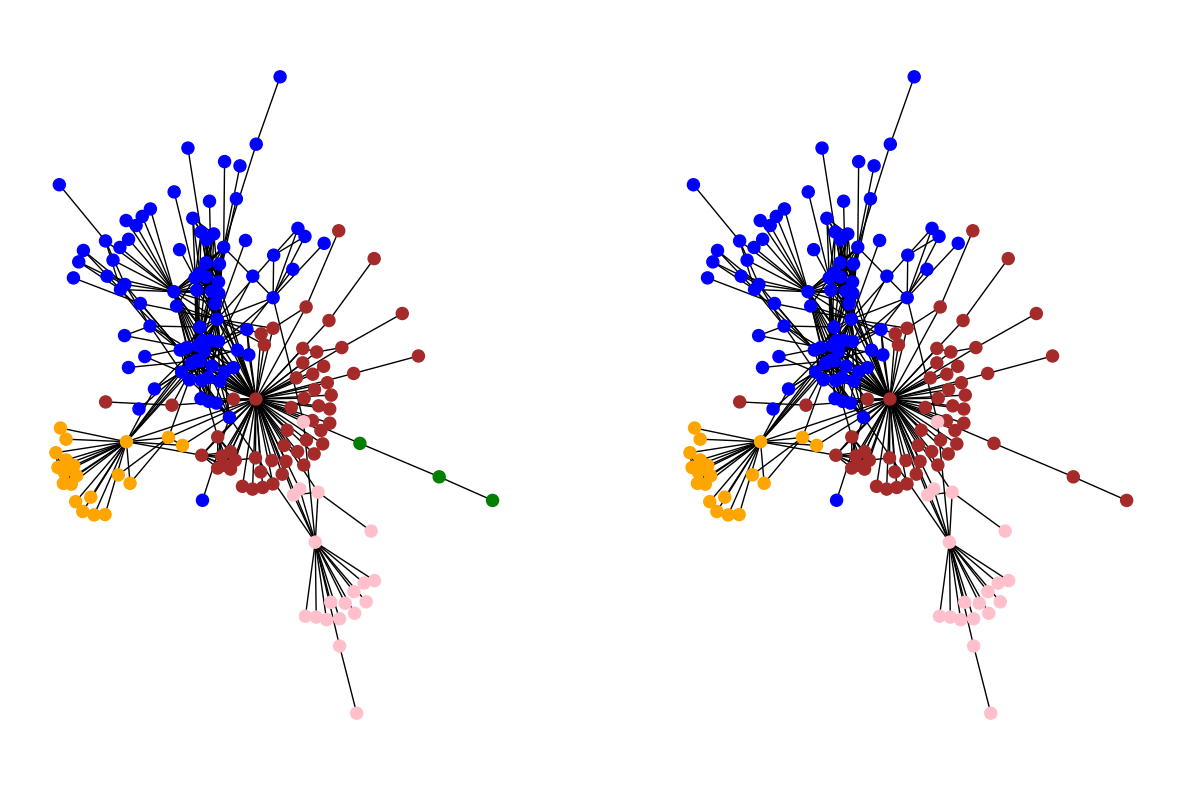

In [7]:
from networkx.algorithms.community import girvan_newman

# Denne deler grafen i stadig flere gjenger (itererer)
generator = girvan_newman(G)
første = next(generator)
andre = next(generator)
tredje = next(generator)
fjerde = next(generator)

# Håper det er færre gjenger enn det er farger
fargeliste = ["blue", "brown", "orange", "pink", "green", "gray", "red", "olive", "purple", "cyan"]

sett_id4 = {}
for snummer, s in enumerate(fjerde):
    for e in s:
        sett_id4[e] = snummer
    #
#
node_farge4 = []
for node in G:
    idx = sett_id4.get(node)
    node_farge4.append(fargeliste[idx])
#

sett_id3 = {}
for snummer, s in enumerate(tredje):
    for e in s:
        sett_id3[e] = snummer
    #
#
node_farge3 = []
for node in G:
    idx = sett_id3.get(node)
    node_farge3.append(fargeliste[idx])
#

# Tegne dem ved siden av hverandre
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 10))

pos = nx.spring_layout(G, seed=10) # Beste seed så langt
nx.draw(G, pos, ax=axes[0], with_labels=False, node_color=node_farge4, font_size=12, node_size=75)
nx.draw(G, pos, ax=axes[1], with_labels=False, node_color=node_farge3, font_size=12, node_size=75)
plt.show()

Trolig liten verdi i den siste gjengen.

#### Louvain

Vi kan se på en gjeng som noder som er tettere knyttet til hverandre enn til resten (de andre nodene).  Det vil si at om vi tar utgangspunkt i en tilfeldig graf (se nedenfor) så vil det være flere kanten i en gjeng enn vi forventer; tettheten er større.

Noder flyttes inn i grupper, og man ser om tettheten "omkring" går opp eller ned når noden flyttes fra en gjeng til en annen.  Man sitter igjen med den optimale delingen i gjenger.

Ulempen er at gjengene er gjensidig utelukkende; neppe representativ for virkeligheten.  Videre, når to nærliggende klikker slås sammen kan det godt tenkes at det er "godt" for den overordnede inndelingen, men at de to i utgangspunktet var tett knyttet går tapt.

kjøretiden er kun $O(n \log n)$ og kan derfor brukes også på svært store grafer.
Info [på Wikipedia](https://en.wikipedia.org/wiki/Louvain_method).

Fant 8 gjenger
Lederne er: ['GA', 'FN', 'XA', 'MA', 'MY', 'JV', 'EN']


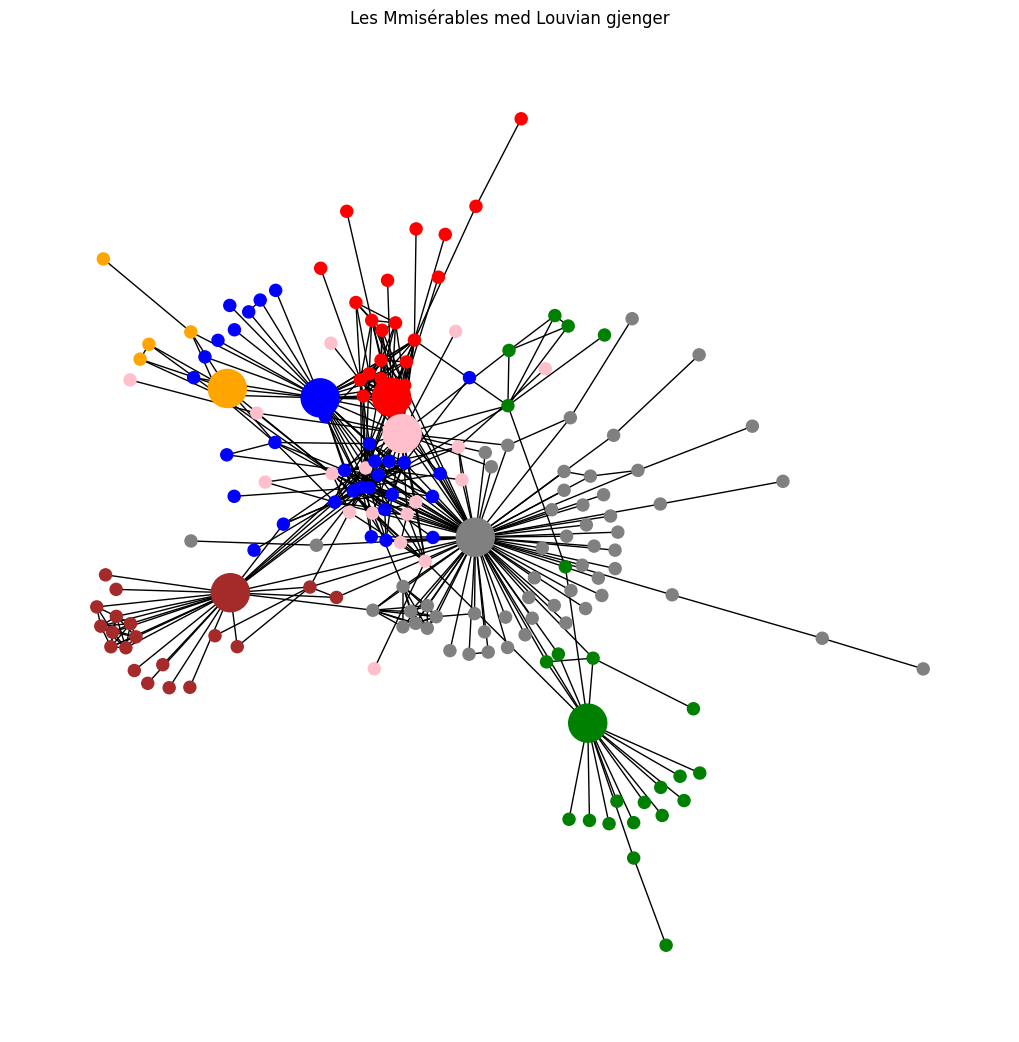

In [11]:
# Community detection with the Louvain Method
from networkx.algorithms.community import louvain_communities

# Calculate best partition for Louvain method
partitions = louvain_communities(G)
print(f"Fant {len(partition)} gjenger")

# Finn de best forbindne i hver gjeng
ledere = []
for p in partitions:
    leder = max(p, key=lambda n:G.degree(n))
    ledere += [leder]
#
print(f"Lederne er: {ledere}")

# Håper det er færre gjenger enn det er farger
fargeliste = ["blue", "brown", "orange", "pink", "green", "gray", "red", "olive", "purple", "cyan"]
node_farge= []
størrelse = 75
node_størrelse = []
# Forutsetter at rekkefølgen er den samme hver gang
for node in G:
    # Hvilken partisjon er denne noden i?
    for idx, l in enumerate(partitions):
        if node in l:
            node_farge.append(fargeliste[idx])
            break
        #
    # Større noder for ledere
    if node in ledere:
        node_størrelse.append(størrelse* 10)
    else:
        node_størrelse.append(størrelse)
    #
#


# Vis frem
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G, seed=10)
nx.draw(G, pos, with_labels=False, node_color=node_farge, font_size=12, node_size=node_størrelse)
plt.title("Les Mmisérables med Louvian gjenger")
plt.show()

# Tilfeldige grafer (Random graph)

En tilfeldig graf er et gitt sett med noder hvor kantene etableres uavhengig av hverandre, med en fast sannsynlighet *p*.  Når $p=1$ er resultatet én (stor) klikk.  En slik graf heter Erdös-Renyi; en kopi av artikkelen [er her](DOC/erdos59random.pdf).  Fordi antallet noder er gitt (*n*) bestemmer sannsynligheten for at kanter opprettes grafens egenskaper; det viser seg at tilfeldige grafer laget med samme parameter er forbløffende like.

Videre, hver kant knytter enten sammen to noder som tidligere var isolerte, knytter én node til et allerede eksisterende nettverk, eller knytter to nettverk sammen.  Det interessante er at hvordan nettverk og klikker dannes skjer som brå faseoverganger.  Mer på om grafer på [Wikipedia](https://en.wikipedia.org/wiki/Network_science) og særlig om [tilfeldidge grafer](https://en.wikipedia.org/wiki/Random_graph).

Antall klikker med størrelse $k$ i en Erdõos-Rényi graf $G(n,p)$ er forventet å være
$$
	F_n(k) := {n \choose k} p^{k \choose 2} {(1-p^k)}^{n-k}
$$
Se [arXiv:2208.07492v1 16 Aug 2022](https://arxiv.org/abs/2208.07492).  Lokal kopi i DOC-katalogen.

Det vil si at om $F_n(k)$ er veldig liten, og vi finner en klikke med $k$ medlemmer, da bør vi kunne konkludere med at klikken er verdt å se nærmere på.

La oss si at en person typisk kjenner 500 mennesker (for en passende definisjon av kjenner).  I Norge bor det 5 millioner.  Det vil si at sannsynligheten for at jeg kjenner en tilfeldig person 1:10.000 eller 0.0001.

In [8]:
from scipy.special import comb

def antall_klikker(n, k, p):
    mulige = comb(n, k)
    prob = p**comb(k, 2)
    rest = (1-(p**k))**(n-k)
    total = mulige * prob * rest
    return(total)
#
ANTALL=5000000
KLIKK=5
SANN=0.0001
print(f"Forventet antall klikker med {KLIKK} medlemmer i en mengde {ANTALL} når sannsynligheten er {SANN} er {antall_klikker(ANTALL, KLIKK, SANN)}")

Forventet antall klikker med 5 medlemmer i en mengde 5000000 når sannsynligheten er 0.0001 er 2.6041614583369804e-09


I en tilfeldig graf er det derfor (svært) få klikker.  Implisitt i dette er at en tilfeldig graf i utgangspunktet ikke kan forventes å "henge sammen".  Men alle er vi med i klikker med mer enn fem medlemmer, så alarmklokkene ringer litt i bakgrunnen nå.  Kommer tilbake til det.

Problemet er å finne dem.  Å finne klikker i grafer er i utgangspunktet NP-komplett, og uten antagelser uansett svært dyrt.

In [35]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import math

In [36]:
# Noen tilfeldige tall for eksempelets skyld
ANTALL = 25000
SANN = 0.01

for i in 5, 6, 7:
    print(f"Forventet antall klikker med {i} noder: {antall_klikker(ANTALL, i, SANN)}")
#rof

start = time.time()
G = nx.gnp_random_graph(ANTALL, SANN)
print(f"Å generere grafen tok {time.time()-start:.2f} sekunder")

print(f"Antall mulige kanter: {ANTALL * (ANTALL-1) / 2}")
print(f"Faktisk antall kanter: {G.number_of_edges()}")

# Finn den største klikken i grafen
start = time.time()
klikker = list(nx.find_cliques(G))
print(f"Å finne største klikken tok {time.time()-start:.2f} sekunder")
# Finn den lengste listen i listen av noder
klikk = max(klikker, key=len)

# Hvem er med
print(f"Største klikk har {len(klikk)} noder: {klikk}")


Forventet antall klikker med 5 noder: 0.8134745747879036
Forventet antall klikker med 6 noder: 3.388807885088253e-07
Forventet antall klikker med 7 noder: 1.2099980910812184e-15
Å generere grafen tok 25.12 sekunder
Antall mulige kanter: 312487500.0
Faktisk antall kanter: 3124206
Å finne største klikken tok 51.22 sekunder
Største klikk har 5 noder: [2459, 12414, 7938, 24547, 17823]


Det kan synes snodig at i en graf med 20.000 noder har største klikken bare en (liten) håndfull noder.  Det er fordi en klikk er en veldig "sterk" datastruktur.

Dersom vi heller ser på største sammenhengende sub-graf.  Den minste sub-grafen har to noder og én kant, deretter tre noder og to kanter, og så videre.

Det viser seg at noe dramatisk skjer når $p\approx1/N$ (hvor $N$ er antall noder).  Da blir gjennomsnittlig antall kanter $\langle k \rangle > 1$ og grafen "klumper" seg.

ANtall kanter i G1: 56
ANtall kanter i G2: 108
ANtall kanter i G3: 178


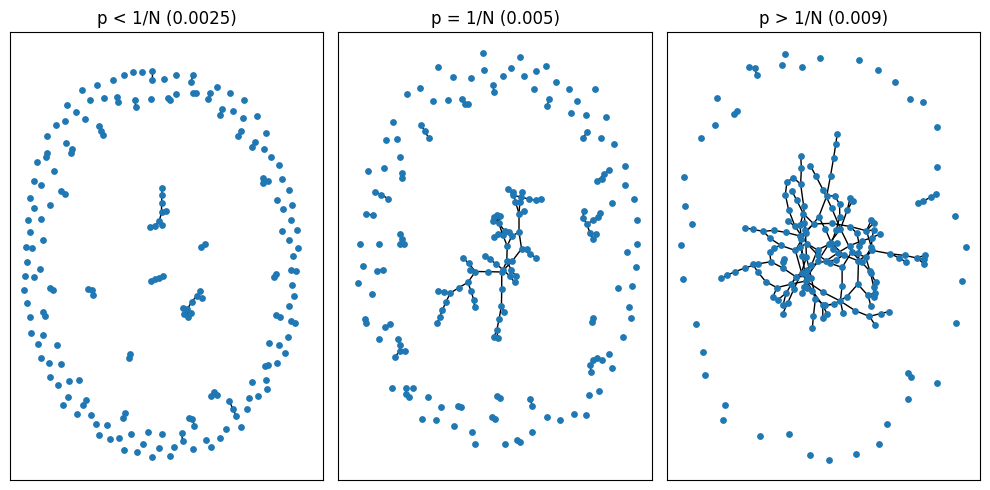

In [37]:
ANTALL = 200
SANN_1 = 0.0025 # < 1/N
SANN_2 = 0.005  # = 1/N
SANN_3 = 0.009  # > 1/N

G1 = nx.gnp_random_graph(ANTALL, SANN_1)
print(f"ANtall kanter i G1: {G1.number_of_edges()}")
G2 = nx.gnp_random_graph(ANTALL, SANN_2)
print(f"ANtall kanter i G2: {G2.number_of_edges()}")
G3 = nx.gnp_random_graph(ANTALL, SANN_3)
print(f"ANtall kanter i G3: {G3.number_of_edges()}")

# Tre sub-plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))

pos1 = nx.spring_layout(G1)
nx.draw_networkx(G1, pos1, with_labels=False, ax=ax1, node_size=15)
ax1.set_title("p < 1/N (0.0025)")

pos2 = nx.spring_layout(G2)
nx.draw_networkx(G2, pos2, with_labels= False, ax=ax2, node_size=15)
ax2.set_title("p = 1/N (0.005)")

pos3 = nx.spring_layout(G3)
nx.draw_networkx(G3, pos3, with_labels=False, ax=ax3, node_size=15)
ax3.set_title("p > 1/N (0.009)")

# Ikke overlapp, takk
plt.tight_layout()
plt.show()

Det er åpenbart stor forskjell på en sub-graf og en klikk!

Som en forberedelse til neste seksjon skal vi se på tettheten.  En grafs "størrelse" er ikke antall noder, fordi en graf med mange noder men få kanter ikke er interessant.  Det som er avgjørende er forholdet mellom antall kanter og antall noder, altså hvor "tett" grafen er.

Tallene vi bruker i eksempelet her kommer fra neste kapittel, og skal brukes til sammenligning, og de er $N=4039, p=0.01$.

Gjennomsnittlig tetthet  $\langle k \rangle$ er hvor mange kanter en tilfeldig node kan forventes å ha.  Ettersom det maksimale antall noder er ${N \choose 2} = \frac{N(N-1)}{2}$ så vil antall kanter (forventes å være) $p \frac{N(N-1)}{2} => 0.01 \frac{4039\times4038}{2} = 81547$.  Ettersom alle kanter genereres tilfeldig, og det maksimal kan være $N-1$ naboer, blir det gjennomsnittlige $p(N-1) \Rightarrow 0.01\times 4038= 40.39$.

Ettersom kantene er generert tilfeldig forvanter vi at standardavviket ikke er høyt.

Det teoretiske standardavviket er $\sigma = \sqrt{p(1-p)(N-1)} \to \sqrt{0.01 \times 0.99 \times 4038} = \sqrt{38.9861} = 6.3234.$



Teoretisk Stdev: 6.3227
Antall kanter med p=0.01 er 81494
Funnet Stdev:   6.2939


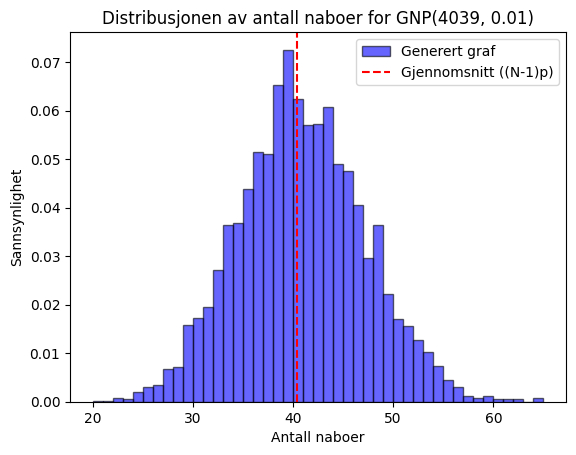

In [38]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import math

# Disse tallene tar vi med oss videre
N = 4039
p = 0.01

teoretisk_std = math.sqrt((N - 1) * p * (1 - p))
print(f"Teoretisk Stdev: {teoretisk_std:.4f}")

# Lag en graf og sjekk resultatet
G = nx.gnp_random_graph(N, p)

print(f"Antall kanter med p={p} er {G.number_of_edges()}")

# ANtall kanter i hver node
antall = []
for node, naboer in G.degree():
    antall += [naboer]
    # eller antall = [d for n, d in G.degree()]
#

# Finn stdev
funnet_std = np.std(antall)

print(f"Funnet Stdev:   {funnet_std:.4f}")

# Vis at Gauss er med
plt.hist(antall, 
         bins=range(min(antall), max(antall) + 1), 
         density=True, 
         alpha=0.6, 
         color='b', 
         edgecolor='black', 
         label='Generert graf')
plt.axvline(x=(N-1)*p, color='r', linestyle='--', label='Gjennomsnitt ((N-1)p)')
plt.xlabel('Antall naboer')
plt.ylabel('Sannsynlighet')
plt.title(f'Distribusjonen av antall naboer for GNP({N}, {p})')
plt.legend()
plt.show()

Selv om det er "lett" å bruke tilfeldige grafer som modell for verden, er det neppe en riktig mdell: Det er (mye) større sannsynlighet at jeg kjenner en av dine venner, enn at jeg kjenner en tilfeldig person et annet sted.  
Vi skal se på to datasett som illustrerer forskjellen.

# Grafer uten skala (_scale free_)



For å så en smak av hvordan virkeligheten kan se ut skal vi laste inn to datasett.  De er svært anderledes enn de tilfeldige grafene vi har sett på så langt.

## Venner på Facebook

In [100]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import gzip

FBG = nx.Graph()
with gzip.open("data/facebook_combined.txt.gz", "r") as fd:
    for linje in fd:
         link = linje.split()
         FBG.add_edge(int(link[0]), int(link[1]))
    #
#
print(f"Antall noder i grafen: {FBG.number_of_nodes()}")
print(f"Antall kanter i grafen: {FBG.number_of_edges()}")


Antall noder i grafen: 4039
Antall kanter i grafen: 88234


Som vi ser er antallet noder og kanter (nesten) likt med grafen vi genererte ovenfor

In [101]:

# ANtall kanter i hver node
antall = []
for node, naboer in FBG.degree():
    antall += [naboer]
    # eller antall = [d for n, d in G.degree()]
#
print(f"Funnet Stdev:   {np.std(antall):.4f}")
print(f"Funnet Median:   {np.mean(antall):.4f}")


Funnet Stdev:   52.4141
Funnet Median:   43.6910


I den tilfeldige grafen standardavviket 6.32 mens her er det 52.  Grafen er åpenbart grunnleggende anderledes.

Å tegne graften tok 56.87 sekunder


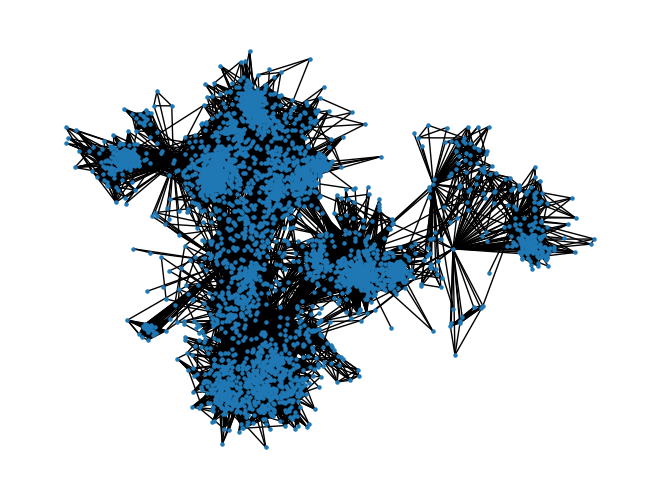

<Figure size 1000x1000 with 0 Axes>

In [98]:
import time

# koden tar ett minutt å kjøre

start = time.time()
pos = nx.spring_layout(FBG)  # Be nodene spre seg utover så godt de kan
nx.draw(FBG, with_labels=False, node_size=5)
print(f"Å tegne graften tok {time.time()-start:.2f} sekunder")

plt.figure(figsize=(10,10))
plt.show()

In [102]:
from ipysigma import Sigma
import math

# En interaktiv versjon

log_degree = {}
for node, deg in FBG.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    FBG, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Sigma(nx.Graph with 4,039 nodes and 88,234 edges)

Problemet er det ikke er mulig å "se" noe i dene figuren.

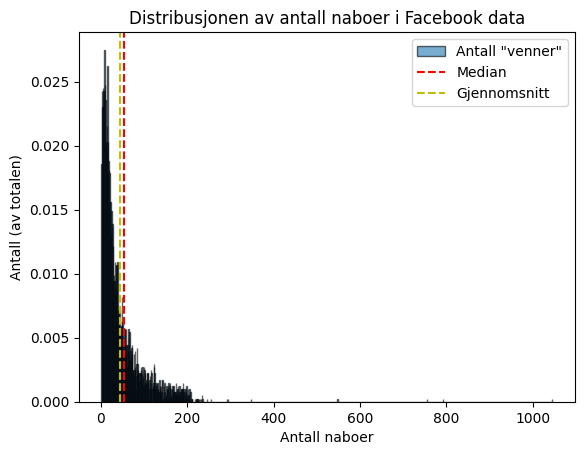

In [42]:
# Vis at Gauss absolutt ikke er med
plt.hist(antall, 
         bins=range(min(antall), max(antall) + 1), 
         density=True, 
         alpha=0.6, 
         edgecolor='black', 
         label='Antall "venner"')
plt.axvline(np.std(antall), color='r', linestyle='--', label='Median')
plt.axvline(np.mean(antall), color='y', linestyle='--', label='Gjennomsnitt')
plt.xlabel('Antall naboer')
plt.ylabel('Antall (av totalen)')
plt.title(f'Distribusjonen av antall naboer i Facebook data')
plt.legend()
plt.show()

Det er åpenbart at grafen ikke er tilfeldig; i det minste ikke i tråd med rammene for en tilfeldig graf.

## Epost fra Network Science

For bedre å forstå situasjonen skal vi se nærmere på et datasett analysert i boken [Network Science](https://networksciencebook.com), nemlig *email* settet som er ett av eksepmplene (se [figur 2.1](https://networksciencebook.com/chapter/2#table-2-1) i [kapittel 2.2](https://networksciencebook.com/chapter/2#networks-graphs)).  Basert på diskusjonen der tegner vi datasettet i $log-log$:

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import gzip

with gzip.open("data/email.edgelist.txt.gz", "rb") as fd:
    data = np.loadtxt(fd, dtype=int)
#
sender = data[:, 0]   # Første kolonne
mottaker = data[:, 1] # Andre kolonne
print(f"Antall kanter totalt: {len(sender)}")

antall_sendere, ut_kanter = np.unique(sender, return_counts=True)
print(f"Hvor mange noder (mennesker) har sendt epost: {len(antall_sendere)}")
antall_mottakere, in_kanter = np.unique(mottaker, return_counts=True)
print(f"Hvor mange noder (mennesker) har mottat epost: {len(antall_mottakere)}")


Antall kanter totalt: 103731
Hvor mange noder (mennesker) har sendt epost: 39797
Hvor mange noder (mennesker) har mottat epost: 30203


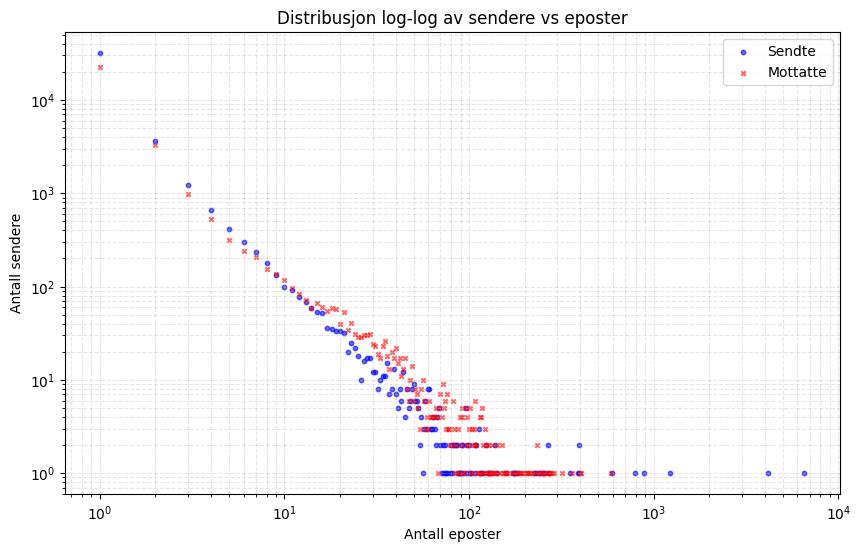

In [11]:
# tell dem opp
ut_x, ut_y = np.unique(ut_kanter, return_counts=True)
inn_x, inn_y = np.unique(in_kanter, return_counts=True)

# Tegn i log-log
plt.figure(figsize=(10, 6))
plt.scatter(ut_x, ut_y, 
            c='blue', 
            alpha=0.6, 
            label='Sendte', 
            s=10, 
            marker='o')
plt.scatter(inn_x, inn_y, 
            c='red', 
            alpha=0.6, 
            label='Mottatte', 
            s=10, 
            marker='x')
# Dette er "power-distribusjon"
plt.xscale('log')
plt.yscale('log')

plt.title("Distribusjon log-log av sendere vs eposter")
plt.xlabel("Antall eposter")
plt.ylabel("Antall sendere")
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.3)

plt.show()



Et blikk forteller oss at $\gt 10^4$ noder (mennesker) har sendt eller mottatt bare én epost, mens én ser ut til å ha sendt nesten $10^4$ eposter.  Forskjellen er dramatisk, for å si det forsiktig.

De horisontale stripene ser ikke ut til å være et resulat av at bøttene på y-aksen er for store.  Det er faktisk bare 1 node for hver av verdiene over circa hundre.

### Lete etter strukturer

In [166]:
# La oss lage en graf
import networkx as nx
import gzip

EG = nx.DiGraph()
# husk at gzip påpner i 'b'
with gzip.open("data/email.edgelist.txt.gz", "rt") as fd:
    for linje in fd:
         link = linje.split()
         EG.add_edge(int(link[0]), int(link[1]))
    #
#
# Bort med eposter sendt til seg selv
EG.remove_edges_from(nx.selfloop_edges(EG))
isolerte = list(nx.isolates(EG)) # kan ikke bruke iteratorer direkte
EG.remove_nodes_from(isolerte)
print(f"Antall noder etter isolerte: {EG.number_of_nodes()}")

Antall noder etter isolerte: 57189


#### Klikker
Definisjonen av en *klikk* er ikke gyldig for en rettet graf (slik epost er).  Men om A sender epost til B (rettet) har jo B åpenbart en relasjon til A.  For å lete etter klikker konverterer vi grafen til urettet graf, og leter der.

Å konvertere en rettet graf til en uten retning virker som en rimelig ting for å se på strukturer.

In [167]:
# Kjører på noen sekunder

#Finn den største klikken i grafen
UG = EG.to_undirected(EG)
klikker = list(nx.find_cliques(UG))
# Finn den lengste listen i listen av noder
største_klikk = max(klikker, key=len)

# Hvem er med
print(f"Største klikk: {len(største_klikk)} medlemmer {største_klikk}")
for i in største_klikk:
    print(f"Node {i}: {len(EG.in_edges(i))} {len(EG.out_edges(i))}")
#

{861: {}, 3718: {}}
Største klikk: 6 medlemmer [732, 13448, 1632, 953, 1730, 18627]
Node 732: 91 0
Node 13448: 4 126
Node 1632: 136 100
Node 953: 68 40
Node 1730: 29 14
Node 18627: 3 4
Å finne viktige noder 0.85 sekunder


Det er overraskende at med 50K noder og 100K eposter har største klikken bare seks medlemmer; det kan naturlitvis være mer enn én klikk med seks medlemmer.  Vi skal se nærmere på dette nedenfor.

I en graf uten skala er det (stor) forskjell mellom "aktiviteten".  Det gjør at mange er marginale.  Det påvirker tettheten.

In [111]:
# Tettheten
tetthet = nx.density(EG)
print(f"Grafens tetthet: {tetthet:.6f}")

Grafens tetthet: 0.000032


Grafen har 50K noder og å finne diameteren tar timesvis.

Vi starter med de ti mest forbundne nodene i datasettet, og velger 10 -- 20 (for å ikke få de mest ekstreme)

In [155]:
SLUTT = 20
sentraliteten = nx.degree_centrality(EG)
# Formatet her er (node, graden) så vi lager en liste sortert på element 1
sorterte_noder = sorted(sentraliteten.items(), key=lambda item: item[1], reverse=True)
top_noder = sorterte_noder[0:SLUTT]
for n,d in top_noder:
    print(n,"\t", d, "\t", EG.degree[n])
#

32199 	 0.11462194866055817 	 6555
11028 	 0.07305728474505141 	 4178
13678 	 0.021473036301321958 	 1228
11798 	 0.019986710498706026 	 1143
13498 	 0.014146324403721062 	 809
180 	 0.010701545778834722 	 612
13027 	 0.010509197733790306 	 601
1335 	 0.008690634398824929 	 497
1965 	 0.007763866545429112 	 444
1882 	 0.0070819052948170955 	 405
290 	 0.007064419108903966 	 404
44530 	 0.006959501993425194 	 398
13106 	 0.0069070434356858085 	 395
14318 	 0.006837098692033294 	 391
1187 	 0.006487374973770722 	 371
1350 	 0.006347485486465692 	 363
867 	 0.006312513114639436 	 361
13034 	 0.00612016506959502 	 350
12586 	 0.005822899909071834 	 333
346 	 0.005787927537245576 	 331


In [102]:
START=10
SLUTT=20
# top ti er altså ikke bokstavelig talt top ti
top_ti = top_noder[START:SLUTT]
for n,d in top_ti:
    print(n,"\t", d, "\t", EG.degree[n])
#

290 	 0.007064419108903966 	 404
44530 	 0.006959501993425194 	 398
13106 	 0.0069070434356858085 	 395
14318 	 0.006837098692033294 	 391
1187 	 0.006487374973770722 	 371
1350 	 0.006347485486465692 	 363
867 	 0.006312513114639436 	 361
13034 	 0.00612016506959502 	 350
12586 	 0.005822899909071834 	 333
346 	 0.005787927537245576 	 331


Nodene på "top ti" har altså kontakt med fra 7 til fem pro mille av totalen.

Er noen av de 20 viktigste nodene med i den største klikken?

In [156]:
# la oss lage en GOTO (for å slippr "Ja Nei"
try:
    for n, d in top_noder:
        if n in største_klikk:
            print("Ja")
            raise
        #
    #
except e:
    pass
else:
    print("Nei")

Nei


#### Lokal tetthet
En klikk krever at absolutt alle snakker med absolutt alle andre.  Det er for sterkt i virkeligheten.  Dersom vi løsner på kravene til en klikk, og heller ser på omgivelsene, da får vi en lokal versjon av tetthet.  På samme måte som **viktige noder** handler om omgivelsene, gjør også lokal tetthet det.

Heller enn en klikk kan vi lete etter steder som er "tette" (har mange forbindelser), uten strengt tatt å oppfylle kravet til en klikk.  Vi kan heller spørre hvor mange av mine naboer som er forbundet med hverandre, som en funksjon av totalt antall (en klikk).  Det vil, i praksis, si antall trekanter noden er med i (de to andre nodene er naboer, og den siste kanten er relasjonen mellom dem).

På utenlandsk heter dette "*local clustering coefficient*.

In [157]:
# Vi konverterer til til en graf som ikke er rettet; om du sender eller mottar en epost 
# har du likevel en relasjon.  Legg merke til at dette reduserer antall kanter!
UG = EG.to_undirected(EG)

# Antall naboer og tettheten rundt de mest forbundne:
for n,d in top_noder:
    print(n,"\t", UG.degree[n], "\t", f"{nx.clustering(UG, n):.5f}")

32199 	 6553 	 0.00004
11028 	 4171 	 0.00012
13678 	 1228 	 0.00013
11798 	 1018 	 0.00154
13498 	 802 	 0.00105
180 	 599 	 0.00022
13027 	 596 	 0.00194
1335 	 448 	 0.00134
1965 	 425 	 0.00009
1882 	 303 	 0.00133
290 	 404 	 0.00014
44530 	 396 	 0.00049
13106 	 395 	 0.00089
14318 	 390 	 0.00166
1187 	 279 	 0.00170
1350 	 363 	 0.00000
867 	 319 	 0.00073
13034 	 350 	 0.00052
12586 	 289 	 0.01223
346 	 238 	 0.00000


De som sender og mottar flest epost har ikke en "gjeng" rundt seg som samsvarer med mengden de sender (eller mottar)

In [159]:
# Finne de nodene som er i tette nabolag

# Fjerne alle noder med få naboer (det hjelper lite med et tett nabolag om nabolaget er lite)
få = 7
beholde = []
for n, d in UG.degree():
    if d > få:
        beholde += [n]
    #
#

store = UG.subgraph(beholde)
print(f"Antall \"store\" noder: {store.number_of_nodes()} og i forhold til totalen {store.number_of_nodes()/UG.number_of_nodes():.3f}")
gode_naboer = nx.clustering(store)
sorterte_naboer = sorted(gode_naboer.items(), key=lambda item: item[1], reverse=True)
for n,d in sorterte_naboer[:10]:
    print(n, d, UG.degree[n])

Antall "store" noder: 2938 og i forhold til totalen 0.051
<class 'dict'>
12 1.0 32
852 1.0 29
995 1.0 8
1447 1.0 12
1547 1.0 19
1562 1.0 9
1626 1.0 24
1950 1.0 9
10573 1.0 9
2434 1.0 8


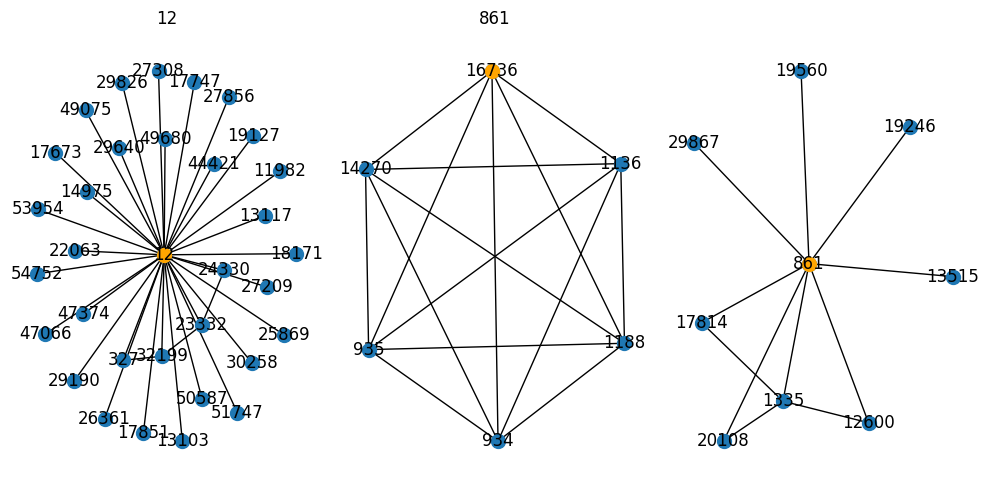

In [177]:
# La oss se på tre av dem
# 12, 18958, 861
# Tre sub-plot

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))

ego1 = nx.ego_graph(UG, 12, radius=1) # hent nabo-nodene fra alle ikke bare de store
pos1 = nx.spring_layout(ego1, seed=42)
nx.draw(ego1, pos1, ax=ax1, with_labels=True,  node_size=100)
# Lag hovednoden orange
nx.draw_networkx_nodes(ego1, pos1, ax=ax1, nodelist=[12], node_color='orange', node_size=100)
ax1.set_title("12")

ego2 = nx.ego_graph(UG, 16736 , radius=1)
pos2 = nx.spring_layout(ego2, seed=42)
nx.draw(ego2, pos2, ax=ax2, with_labels=True,  node_size=100)
nx.draw_networkx_nodes(ego2, pos2, ax=ax2, nodelist=[16736], node_color='orange', node_size=100)
ax2.set_title("16736 ")

ego3 = nx.ego_graph(UG, 861 , radius=1)
pos3 = nx.spring_layout(ego3, seed=42)
nx.draw(ego3, pos3, ax=ax3, with_labels=True,  node_size=100)
nx.draw_networkx_nodes(ego3, pos3, ax=ax3, nodelist=[861], node_color='orange', node_size=100)
ax3.set_title("861")

# Ikke overlapp, takk
plt.tight_layout()
plt.show()

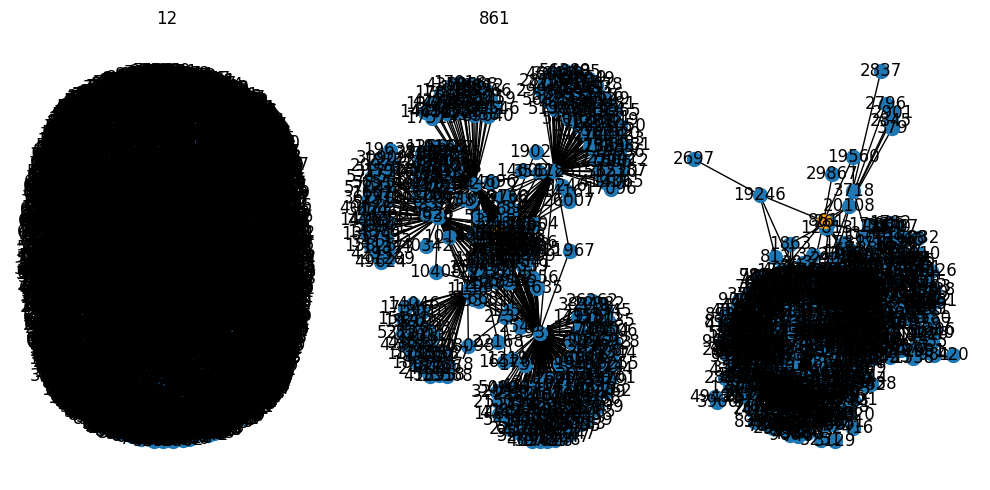

In [180]:
# Se hele nabolaget for de samme tre
# 12, 18958, 861
# Tre sub-plot
# Blir bare sorte "hull"

# Tar et minutter eller så å kjøre

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 5))

ego1 = nx.ego_graph(UG, 12, radius=2) # hent nabo-nodene fra alle ikke bare de store
pos1 = nx.spring_layout(ego1, seed=42)
nx.draw(ego1, pos1, ax=ax1, with_labels=True,  node_size=100)
# Lag hovednoden orange
nx.draw_networkx_nodes(ego1, pos1, ax=ax1, nodelist=[12], node_color='orange', node_size=100)
ax1.set_title("12")

ego2 = nx.ego_graph(UG, 16736 , radius=2)
pos2 = nx.spring_layout(ego2, seed=42)
nx.draw(ego2, pos2, ax=ax2, with_labels=True,  node_size=100)
nx.draw_networkx_nodes(ego2, pos2, ax=ax2, nodelist=[16736], node_color='orange', node_size=100)
ax2.set_title("16736 ")

ego3 = nx.ego_graph(UG, 861 , radius=2)
pos3 = nx.spring_layout(ego3, seed=42)
nx.draw(ego3, pos3, ax=ax3, with_labels=True,  node_size=100)
nx.draw_networkx_nodes(ego3, pos3, ax=ax3, nodelist=[861], node_color='orange', node_size=100)
ax3.set_title("861")

# Ikke overlapp, takk
plt.tight_layout()
plt.show()

In [193]:
from ipysigma import Sigma
import math

log_degree = {}
for node, deg in ego2.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    ego2, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Sigma(nx.Graph with 344 nodes and 570 edges)

Vi forsøker å splitte opp datasettet i gjenger

In [189]:
# Tar noen sekunder

# Community detection with the Louvain Method
from networkx.algorithms.community import louvain_communities

# Louvain.  Burde brukt Leiden men da blir det mye GPU-greier
partition = louvain_communities(UG)

# Hvor mange fant vi
print(f"Vi fant {len(partition)} gjenger")
print(partition[0])

Vi fant 287 gjenger
{40960, 45061, 47112, 16394, 12299, 55306, 19, 45078, 47128, 32793, 51226, 53275, 43034, 32795, 14361, 32799, 22564, 53285, 26661, 28708, 16425, 38954, 51241, 12338, 47154, 14387, 20534, 36921, 49211, 6204, 55356, 4157, 51264, 12353, 55365, 55366, 55368, 24649, 26696, 55369, 22602, 26708, 12373, 20566, 10330, 14426, 26717, 20574, 47198, 34913, 28771, 30820, 30821, 22630, 18534, 18535, 18537, 18536, 32869, 32876, 41071, 39025, 28788, 55413, 26742, 53372, 55421, 12420, 53383, 26762, 26763, 28812, 144, 18579, 18580, 28822, 10394, 22683, 47259, 22690, 37029, 45222, 43184, 2229, 37045, 51385, 190, 32960, 196, 28874, 20683, 47309, 47310, 47315, 28885, 18652, 18653, 47326, 16611, 30947, 51429, 16620, 45295, 47344, 47346, 35058, 12532, 47349, 53493, 22777, 28922, 18687, 37122, 22788, 22789, 2308, 35080, 20746, 14606, 45328, 28946, 47380, 49428, 51484, 14620, 41254, 43305, 47402, 10539, 4396, 53549, 305, 53555, 53557, 20789, 315, 316, 45374, 31042, 53575, 51528, 55634, 2389,

In [196]:
# Se på den første

from ipysigma import Sigma
import math

gjengen = UG.subgraph(partition[0])

log_degree = {}
for node, deg in gjengen.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    gjengen, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Sigma(nx.Graph with 904 nodes and 1,302 edges)

In [202]:
from ipysigma import Sigma
import math

gjengen = UG.subgraph(partition[0]).copy()
# Identify nodes with degree 1
bladnoder = []
for n,d in gjengen.degree():
    if d < 3:
        bladnoder += [n]
    #
#

gjengen.remove_nodes_from(bladnoder)
log_degree = {}
for node, deg in gjengen.degree():
    log_degree[node] = math.log(deg + 1) 
#    
Sigma(
    gjengen, 
    node_size=log_degree,
    node_color=log_degree,
    node_color_gradient="Plasma",
    node_size_range=(1, 30),
    default_edge_type="curve"
)

Sigma(nx.Graph with 146 nodes and 485 edges)

## Sammendrag

- Det er veldig vanskelig å få oversikt over en ikke-triviell graf
- Vi må ha noe å lete etter